# **1. Perkenalan Dataset**


1. **Sumber Dataset**:  Healthcare Cybersecurity Vulnerabilities Dataset

- Nama dataset: `healthcare_cybersecurity_10k` (file: `healthcare_cybersecurity_10k.csv`)
- Sumber Kaggle: <https://www.kaggle.com/datasets/chuneeb/healthcare-cybersecurity-vulnerabilities-dataset>
- Sumber data (origin): National Vulnerability Database (NVD) — NIST (NVD format CVE)
- Deskripsi dataset: berisi 1,515 record CVE terkait healthcare cybersecurity, mencakup deskripsi kerentanan, severity, skor CVSS, attack vector, weakness (CWE), dan referensi.
- Keterangan kolom (data dictionary):

| Atribut                | Tipe            | Deskripsi                                                                          |
| ---------------------- | --------------- | ---------------------------------------------------------------------------------- |
| CVE\_ID                | string          | Identifier unik untuk vulnerability berdasarkan skema CVE (mis. CVE-2017-xxxxx).   |
| Keyword                | string          | Kata kunci/konteks pencarian yang mengelompokkan entri (mis. medical device).      |
| Published              | datetime64\[us] | Tanggal publikasi/rilis entri vulnerability.                                       |
| Last\_Modified         | datetime64\[us] | Tanggal terakhir entri diperbarui pada sumber data.                                |
| Status                 | string          | Status entri pada sumber (contoh umum: Modified, Deferred).                        |
| Description            | string          | Deskripsi teks vulnerability (fitur utama untuk model berbasis teks).              |
| Severity               | string          | Label tingkat keparahan kualitatif (LOW/MEDIUM/HIGH/CRITICAL).                     |
| CVSS\_Score            | float64         | Skor CVSS numerik (0–10) sebagai representasi tingkat risiko.                      |
| Attack\_Vector         | string          | Vektor serangan (mis. NETWORK, LOCAL, ADJACENT\_NETWORK, PHYSICAL).                |
| Weakness               | string          | Label kelemahan/kelas bug (umumnya CWE-xxx atau label NVD seperti NVD-CWE-noinfo). |
| Reference              | string          | Daftar referensi/tautan terkait vulnerability (biasanya berisi URL).               |
| Description\_Length    | int64           | Fitur turunan: panjang deskripsi (jumlah karakter).                                |
| Description\_WordCount | int64           | Fitur turunan: jumlah kata pada deskripsi.                                         |
| Reference\_Count       | int64           | Fitur turunan: jumlah URL yang terdeteksi pada kolom Reference.                    |
| Published\_Year        | int32           | Fitur turunan: tahun dari Published.                                               |
| Published\_Month       | string          | Fitur turunan: bulan (YYYY-MM) dari Published.                                     |

- Tujuan: Membangun sistem Machine Learning end-to-end yang dapat:
  - Melakukan preprocessing data secara otomatis
  - Melatih model dengan hyperparameter tuning
  - Mengimplementasikan CI/CD
  - Monitoring dengan tools monitoring statistik dataset
- Statistik ringkas:

```text
Rows (raw)            : 1515
Columns (raw)         : 11
Rows (preprocessed)   : 1515
Columns (preprocessed): 11
Rows (features)       : 1515
Columns (features)    : 16
Unique CVE_ID         : 1515
Published date range  : 2004-12-15 → 2026-04-20

Top Severity (preprocessed):
MEDIUM   :   720
HIGH     :   492
CRITICAL :   151
LOW      :   134

Top Attack Vector (preprocessed):
NETWORK          :  1279
LOCAL            :   134
ADJACENT_NETWORK :    64
PHYSICAL         :    20

Missingness after preprocessing (%):
Attack_Vector :  1.19
CVSS_Score    :  1.19
Severity      :  1.19
Weakness      :  0.07
```


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Pengaturan visualisasi standar
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Menghilangkan warning agar output notebook rapi
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [31]:
import kagglehub
import os

# Download the healthcare cybersecurity vulnerabilities dataset
path = kagglehub.dataset_download("chuneeb/healthcare-cybersecurity-vulnerabilities-dataset")

print("Path to dataset files:", path)

# Identify the CSV file and load it
files = [f for f in os.listdir(path) if f.endswith('.csv')]
if files:
    file_path = os.path.join(path, files[0])
    df = pd.read_csv(file_path)
    print(f"Successfully loaded: {files[0]}")
else:
    print("No CSV file found in the dataset path.")

Using Colab cache for faster access to the 'healthcare-cybersecurity-vulnerabilities-dataset' dataset.
Path to dataset files: /kaggle/input/healthcare-cybersecurity-vulnerabilities-dataset
Successfully loaded: healthcare_cybersecurity_10k.csv


In [39]:
# Melihat 5 baris pertama
display(df.head())

# Melihat informasi umum mengenai tipe data dan jumlah baris
df.info()

,CVE_ID,Keyword,Published,Last_Modified,Status,Description,Severity,CVSS_Score,Attack_Vector,Weakness,Reference
0,CVE-2011-3386,medical device,2011-09-02,2025-04-11,Deferred,Unspecified vulnerability in Medtronic Paradig...,MEDIUM,4.0,NETWORK,NVD-CWE-noinfo,http://sixuntilme.com/blog2/2011/08/hacked_jay...
1,CVE-2017-12718,medical device,2018-02-15,2024-11-21,Modified,A Classic Buffer Overflow issue was discovered...,MEDIUM,6.8,NETWORK,CWE-120,http://www.securityfocus.com/bid/100665
2,CVE-2017-14002,medical device,2018-03-20,2024-11-21,Modified,GE Infinia/Infinia with Hawkeye 4 medical imag...,HIGH,10.0,NETWORK,CWE-287,http://www.securityfocus.com/bid/103405
3,CVE-2017-14006,medical device,2018-03-20,2024-11-21,Modified,"GE Xeleris versions 1.0,1.1,2.1,3.0,3.1, medic...",HIGH,7.5,NETWORK,CWE-287,https://ics-cert.us-cert.gov/advisories/ICSMA-...
4,CVE-2019-5024,medical device,2019-04-11,2024-11-21,Modified,A restricted environment escape vulnerability ...,HIGH,7.6,PHYSICAL,CWE-693,https://talosintelligence.com/vulnerability_re...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1515 entries, 0 to 1514
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CVE_ID         1515 non-null   object 
 1   Keyword        1515 non-null   object 
 2   Published      1515 non-null   object 
 3   Last_Modified  1515 non-null   object 
 4   Status         1515 non-null   object 
 5   Description    1515 non-null   object 
 6   Severity       1497 non-null   object 
 7   CVSS_Score     1497 non-null   float64
 8   Attack_Vector  1497 non-null   object 
 9   Weakness       1514 non-null   object 
 10  Reference      1515 non-null   object 
dtypes: float64(1), object(10)
memory usage: 130.3+ KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [40]:
# Cek missing values dan data duplikat
missing_vals = df.isnull().sum()
print("Kolom dengan Missing Values:")
print(missing_vals[missing_vals > 0])

print("\nJumlah baris duplikat (semua kolom):", df.duplicated().sum())
if 'CVE_ID' in df.columns:
    print("Jumlah duplikasi pada CVE_ID:", df['CVE_ID'].duplicated().sum())

Kolom dengan Missing Values:
Severity         18
CVSS_Score       18
Attack_Vector    18
Weakness          1
dtype: int64

Jumlah baris duplikat (semua kolom): 0
Jumlah duplikasi pada CVE_ID: 0


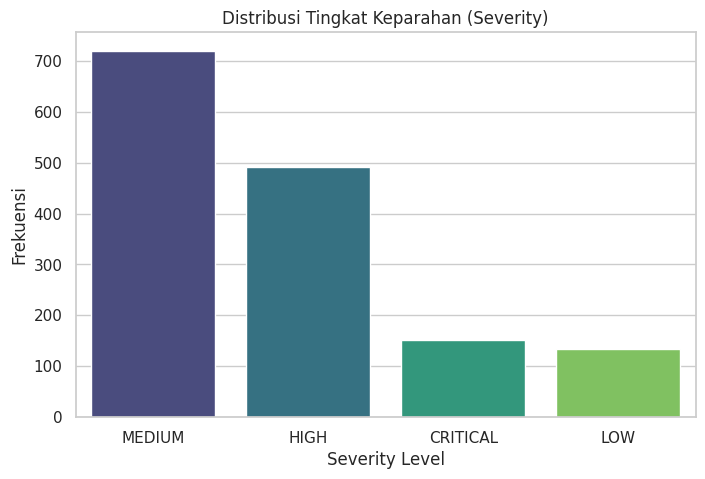

In [41]:
# Distribusi Tingkat Keparahan (Severity)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Severity', order=df['Severity'].value_counts().index, palette='viridis')
plt.title('Distribusi Tingkat Keparahan (Severity)')
plt.xlabel('Severity Level')
plt.ylabel('Frekuensi')
plt.show()

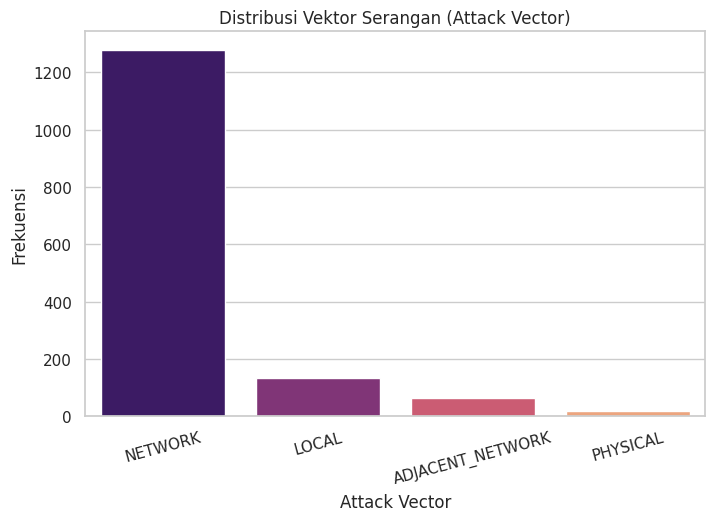

In [42]:
# Distribusi Attack Vector
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Attack_Vector', order=df['Attack_Vector'].value_counts().index, palette='magma')
plt.title('Distribusi Vektor Serangan (Attack Vector)')
plt.xlabel('Attack Vector')
plt.ylabel('Frekuensi')
plt.xticks(rotation=15)
plt.show()

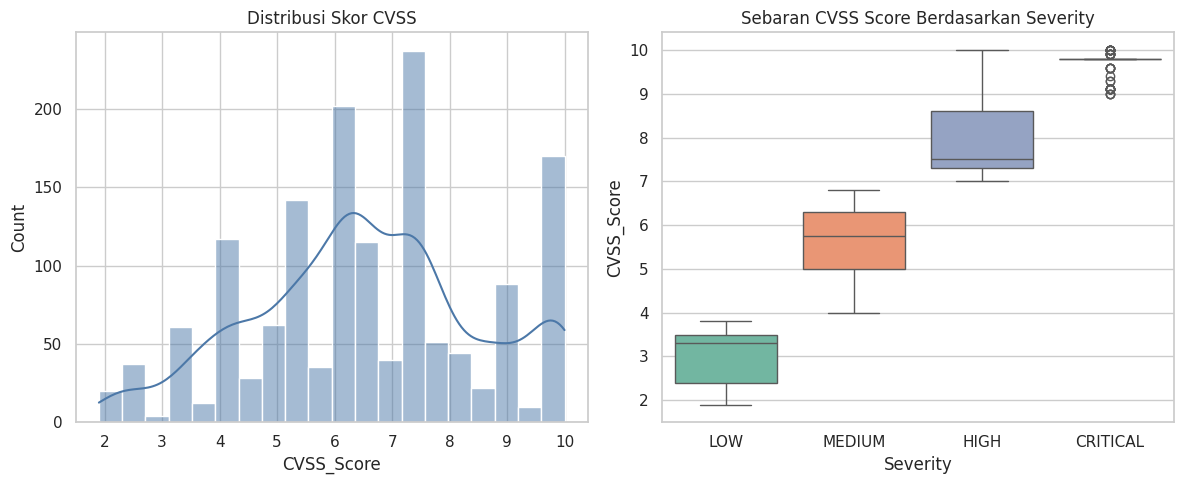

In [43]:
# Distribusi dan Persebaran CVSS Score
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['CVSS_Score'].dropna(), bins=20, kde=True, color='#4C78A8')
plt.title('Distribusi Skor CVSS')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Severity', y='CVSS_Score',
            order=['LOW', 'MEDIUM', 'HIGH', 'CRITICAL'], palette='Set2')
plt.title('Sebaran CVSS Score Berdasarkan Severity')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

## 5.1 Menangani Data Kosong (Missing Values)

Kita mengisi data kosong untuk kolom kategorikal dengan `UKNOWN` dan kolom numerik (`CVSS_Score`) menggunakan median untuk meminimalisir outlier.

In [44]:
df_clean = df.copy()

# Imputasi numerik
if 'CVSS_Score' in df_clean.columns:
    median_cvss = df_clean['CVSS_Score'].median()
    df_clean['CVSS_Score'] = df_clean['CVSS_Score'].fillna(median_cvss)

# Imputasi kategorikal
cat_cols = ['Severity', 'Attack_Vector', 'Weakness', 'Status', 'Keyword']
for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("UNKNOWN")

print("Jumlah missing values setelah imputasi:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0]) # Hanya menampilkan jika masih ada sisa
print("Tidak ada missing value tersisa.")

Jumlah missing values setelah imputasi:
Series([], dtype: int64)
Tidak ada missing value tersisa.


## 5.2 Menghapus Data Duplikat

Langkah berjaga-jaga jika ada baris data ganda atau identifier ganda (`CVE_ID`) yang bisa membuat _leakage_ pada permodelan.

In [45]:
print(f"Banyak baris sebelum drop duplikat: {len(df_clean)}")
df_clean = df_clean.drop_duplicates()
if 'CVE_ID' in df_clean.columns:
    df_clean = df_clean.drop_duplicates(subset=['CVE_ID'])
print(f"Banyak baris setelah drop duplikat  : {len(df_clean)}")

Banyak baris sebelum drop duplikat: 1515
Banyak baris setelah drop duplikat  : 1515


### 5.3. Deteksi dan Penanganan Outlier
Mendeteksi *outlier* pada fitur numerik utama seperti `CVSS_Score` menggunakan batasan Interquartile Range (IQR). Nilai ekstrem kemudian kita pangkas (Winsorization) ke nilai batas.

In [46]:
if 'CVSS_Score' in df_clean.columns:
    Q1 = df_clean['CVSS_Score'].quantile(0.25)
    Q3 = df_clean['CVSS_Score'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identifikasi outlier
    outliers = df_clean[(df_clean['CVSS_Score'] < lower_bound) | (df_clean['CVSS_Score'] > upper_bound)]
    print(f"Jumlah outlier yang terdeteksi pada CVSS_Score: {len(outliers)}")
    print(f"Batas bawah (Lower Bound): {lower_bound:.3f}")
    print(f"Batas atas (Upper Bound): {upper_bound:.3f}")

    # Penanganan dengan Capping/Winsorization
    df_clean['CVSS_Score'] = df_clean['CVSS_Score'].clip(lower=lower_bound, upper=upper_bound)
    print("\nOutlier telah dibatasi (capped) sesuai batasan IQR.")

Jumlah outlier yang terdeteksi pada CVSS_Score: 19
Batas bawah (Lower Bound): 2.100
Batas atas (Upper Bound): 10.900

Outlier telah dibatasi (capped) sesuai batasan IQR.


Secara metode statistik IQR, terdeteksi 19 anomali yang skornya di bawah angka `2.10`. Secara otomatis batas bawah dataset kita dibatasi menggunakan `clip()`. Hal ini penting agar model ML nantinya tidak terlalu terdistraksi (kaget) saat harus mencerna deviasi nilai yang terlampau jauh dari mayoritas data.

### 5.4. Normalisasi atau Standarisasi Fitur
Menerapkan standarisasi (Z-score) pada `CVSS_Score` agar datanya memiliki rata-rata 0 dan standar deviasi 1. Berguna untuk algoritma *Distance-based*.

In [47]:
scaler = StandardScaler()
if 'CVSS_Score' in df_clean.columns:
    df_clean['CVSS_Score_Scaled'] = scaler.fit_transform(df_clean[['CVSS_Score']])

    print("Statistik CVSS_Score setelah dilakukan standarisasi:")
    display(df_clean[['CVSS_Score_Scaled']].describe().round(3))

Statistik CVSS_Score setelah dilakukan standarisasi:


,CVSS_Score_Scaled
count,1515.000
mean,0.000
std,1.000
min,-2.292
25%,-0.594
50%,-0.028
75%,0.538
max,1.774


Nilai `mean` (rata-rata) kini berpusat tepat pada `0.0` dan standar deviasi `std` berada di titik `1.0`. Normalisasi ini menghilangkan kendala kesenjangan skala metrik. Algoritma matematis seperti SVM atau KNN kini bisa membandingkan jarak numerik kolom ini dengan kolom lain secara sepadan.

### 5.5. Encoding Data Kategorikal
Membuat representasi numerik menggunakan One-Hot Encoding dari data kategorikal, seperti `Severity` dan `Attack_Vector`.

In [48]:
cols_to_encode = [col for col in ['Severity', 'Attack_Vector'] if col in df_clean.columns]
df_encoded = pd.get_dummies(df_clean, columns=cols_to_encode, drop_first=False)

# Menampilkan sample fitur One-Hot Encoding
encoded_cols = [c for c in df_encoded.columns if any(c.startswith(cc + "_") for cc in cols_to_encode)]
print("Hasil kolom dari One-Hot Encoding:")
display(df_encoded[encoded_cols].head())

Hasil kolom dari One-Hot Encoding:


,Severity_CRITICAL,Severity_HIGH,Severity_LOW,Severity_MEDIUM,Severity_UNKNOWN,Attack_Vector_ADJACENT_NETWORK,Attack_Vector_LOCAL,Attack_Vector_NETWORK,Attack_Vector_PHYSICAL,Attack_Vector_UNKNOWN
0,False,False,False,True,False,False,False,True,False,False
1,False,False,False,True,False,False,False,True,False,False
2,False,True,False,False,False,False,False,True,False,False
3,False,True,False,False,False,False,False,True,False,False
4,False,True,False,False,False,False,False,False,True,False


Teks `CRITICAL` atau `NETWORK` sudah dijabarkan menjadi matriks biner (`True`/`False` atau `1`/`0`). Algoritma komputasi kini bisa secara matematis mengenali pola vektor serangan tanpa gagal membaca teks string.

### 5.6. Binning (Pengelompokan Data)
Mengkategorikan `CVSS_Score` yang tadinya rasio numerik ke dalam grup kategori risiko yang lebih bermakna (LOW, MEDIUM, HIGH, CRITICAL).

In [49]:
if 'CVSS_Score' in df_clean.columns:
    # Menetapkan batas sesuai standar umum CVSS v3
    bins = [-0.1, 3.9, 6.9, 8.9, 10.0]
    labels = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']

    df_clean['CVSS_Risk_Bin'] = pd.cut(df_clean['CVSS_Score'], bins=bins, labels=labels)

    print("Distribusi frekuensi setelah Binning (CVSS_Risk_Bin):")
    print(df_clean['CVSS_Risk_Bin'].value_counts())

    print("\nSample data hasil Binning:")
    display(df_clean[['CVSS_Score', 'CVSS_Risk_Bin']].head())

Distribusi frekuensi setelah Binning (CVSS_Risk_Bin):
CVSS_Risk_Bin
MEDIUM      738
HIGH        448
CRITICAL    195
LOW         134
Name: count, dtype: int64

Sample data hasil Binning:


,CVSS_Score,CVSS_Risk_Bin
0,4.0,MEDIUM
1,6.8,MEDIUM
2,10.0,CRITICAL
3,7.5,HIGH
4,7.6,HIGH


Binning ini mengelompokkan ulang skor presisi ke dalam struktur `MEDIUM=738`, `HIGH=448`, dst. Jika model Anda dirancang sebagai **Klasifikasi Klasik**, pengelompokan ini mempermudah mesin untuk memberikan hasil prediksi tindakan/kategori (*actionable category*) alih-alih angka desimal acak yang butuh interpretasi dua kali.

### Kesimpulan Akhir
Data kita (dalam variabel matriks `df_encoded`) saat ini sudah bertransformasi dari sekadar 'log kerentanan mentah' menjadi kumpulan data matematis murni yang sangat rapi. Pra-pemrosesan ini sudah menuntaskan isu data kosong, anomali nilai, *scaling*, dan translasi teks kategorikal, membuat *dataset* ini lulus uji dan sepenuhnya siap untuk masuk ke tahap **Pelatihan Model (Model Training)**.

# Simpan Sebagai Dataset yang Bersih


In [50]:
import os

cwd = os.getcwd()
base_dir = os.path.dirname(cwd) if os.path.basename(cwd) == "preprocessing" else cwd

output_dir = os.path.join(base_dir, "preprocessing", "dataset_preprocessing")
os.makedirs(output_dir, exist_ok=True)

df_to_save = df_encoded if "df_encoded" in globals() else df_clean
output_path = os.path.join(output_dir, "healthcare_cybersecurity_preprocessing.csv")
df_to_save.to_csv(output_path, index=False)

relative_output_path = os.path.relpath(output_path, start=base_dir).replace(os.sep, "/")
print(f"Saved preprocessed dataset to: {relative_output_path}")
print(f"Shape: {df_to_save.shape}")

Saved preprocessed dataset to: preprocessing/dataset_preprocessing/healthcare_cybersecurity_preprocessing.csv
Shape: (1515, 20)
